In [2]:
import pandas as pd
import plotly.express as px

df1 = pd.read_csv("student_lifestyle_dataset.csv")
df2 = pd.read_csv("Gaming_Academic_Performance.csv")
df3_mat = pd.read_csv("student-mat.csv", sep=";")
df3_por = pd.read_csv("student-por.csv", sep=";")
df4 = pd.read_csv("student_habits_performance.csv")

In [3]:
df1.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [4]:
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

In [14]:
df3.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,Subject,Grade Group
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,Math,Low
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,Math,Low
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,Math,Low
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,Math,High
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,Math,Low


In [15]:
df3_mat = pd.read_csv("student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("student-por.csv", sep=None, engine="python")

In [16]:
# Add subject column
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"

# Merge / append Math + Portuguese into one table
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

In [17]:
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

df1 = add_grade_group(df1, "GPA")
df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_score")

In [18]:
# Create Grade Group by balanced percentile
df3 = add_grade_group(df3, "G3")

# Check result
df3[["Subject", "studytime", "paid", "absences", "G3", "Grade Group"]].head()

,Subject,studytime,paid,absences,G3,Grade Group
0,Math,2,no,6,6,Low
1,Math,2,no,4,6,Low
2,Math,2,yes,10,10,Low
3,Math,3,yes,2,15,High
4,Math,2,yes,4,10,Low


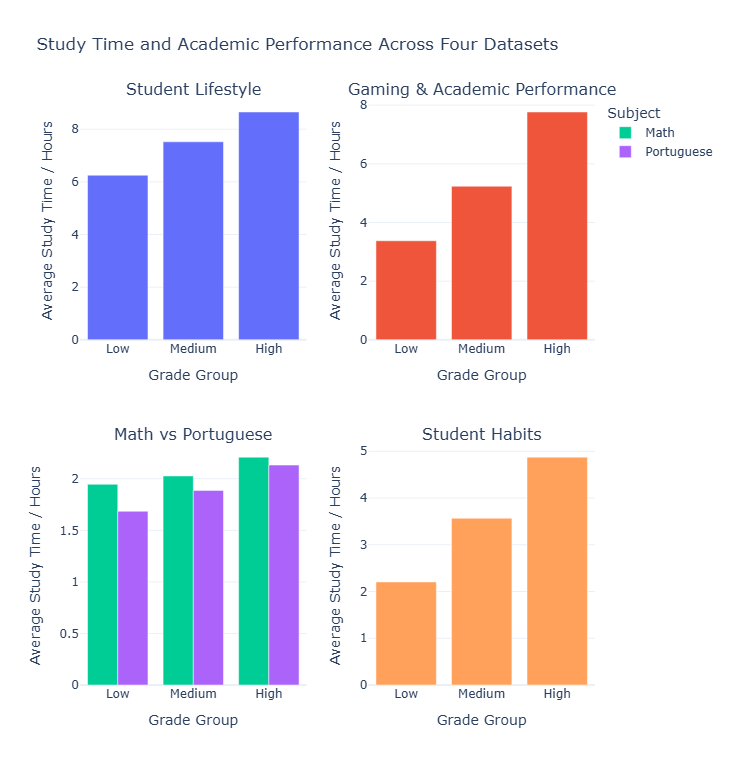

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

grade_order = ["Low", "Medium", "High"]

s1 = df1.groupby("Grade Group", observed=False)["Study_Hours_Per_Day"].mean().reindex(grade_order)
s2 = df2.groupby("Grade Group", observed=False)["study_hours"].mean().reindex(grade_order)

s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["studytime"]
    .mean()
    .reset_index()
)

s4 = df4.groupby("Grade Group", observed=False)["study_hours_per_day"].mean().reindex(grade_order)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Student Lifestyle",
        "Gaming & Academic Performance",
        "Math vs Portuguese",
        "Student Habits"
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(x=grade_order, y=s1.values, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=grade_order, y=s2.values, showlegend=False), row=1, col=2)

for subject in ["Math", "Portuguese"]:
    temp = s3[s3["Subject"] == subject].set_index("Grade Group").reindex(grade_order)
    fig.add_trace(
        go.Bar(x=grade_order, y=temp["studytime"], name=subject),
        row=2,
        col=1
    )

fig.add_trace(go.Bar(x=grade_order, y=s4.values, showlegend=False), row=2, col=2)

fig.update_layout(
    title_text="Study Time and Academic Performance Across Four Datasets",
    barmode="group",
    height=750,
    width=1000,
    template="plotly_white",
    legend_title_text="Subject"
)

fig.update_xaxes(title_text="Grade Group")
fig.update_yaxes(title_text="Average Study Time / Hours")

fig.show()